In [1]:
!pip install pandas numpy matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable


In [2]:
# Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Load the dataset
df = pd.read_csv(r"C:\Users\LENOVO\Documents\CodeAlpha_EDA_Visualization\Diabetes Dataset\diabetes.csv")

# Preview the first 5 rows
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape of dataset: (768, 9)

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# Understand the dataset structure
print("Column names:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nOutcome distribution:")
print(df['Outcome'].value_counts())

Column names: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Data types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Missing values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Outcome distribution:
Outcome
0    500
1    268
Name: count, dtype: int64


In [5]:
# Full statistical summary
print("Statistical Summary:")
df.describe().round(2)

Statistical Summary:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


In [6]:
# Replace medically impossible zeros with NaN
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)

# Check how many missing values we now have
print("Missing values after replacing zeros:")
print(df.isnull().sum())

Missing values after replacing zeros:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [7]:
# Fill missing values with the median of each column
df[cols_with_zeros] = df[cols_with_zeros].fillna(df[cols_with_zeros].median())

# Confirm no missing values remain
print("Missing values after filling with median:")
print(df.isnull().sum())
print("\nDataset is clean and ready for analysis!")

Missing values after filling with median:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Dataset is clean and ready for analysis!


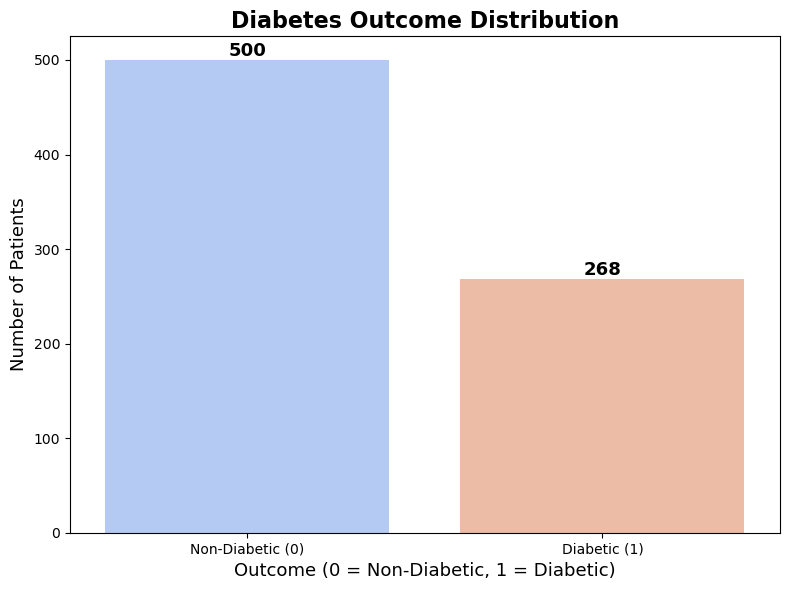

Chart 1 saved!


In [8]:
# Create charts output folder
import os
output_folder = r"C:\Users\LENOVO\Documents\CodeAlpha_EDA_Visualization\charts"
os.makedirs(output_folder, exist_ok=True)

# Chart 1 - Outcome Distribution
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Outcome', data=df, palette='coolwarm')
plt.title('Diabetes Outcome Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Outcome (0 = Non-Diabetic, 1 = Diabetic)', fontsize=13)
plt.ylabel('Number of Patients', fontsize=13)
plt.xticks([0, 1], ['Non-Diabetic (0)', 'Diabetic (1)'])

# Add count labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(output_folder, '1_outcome_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved!")

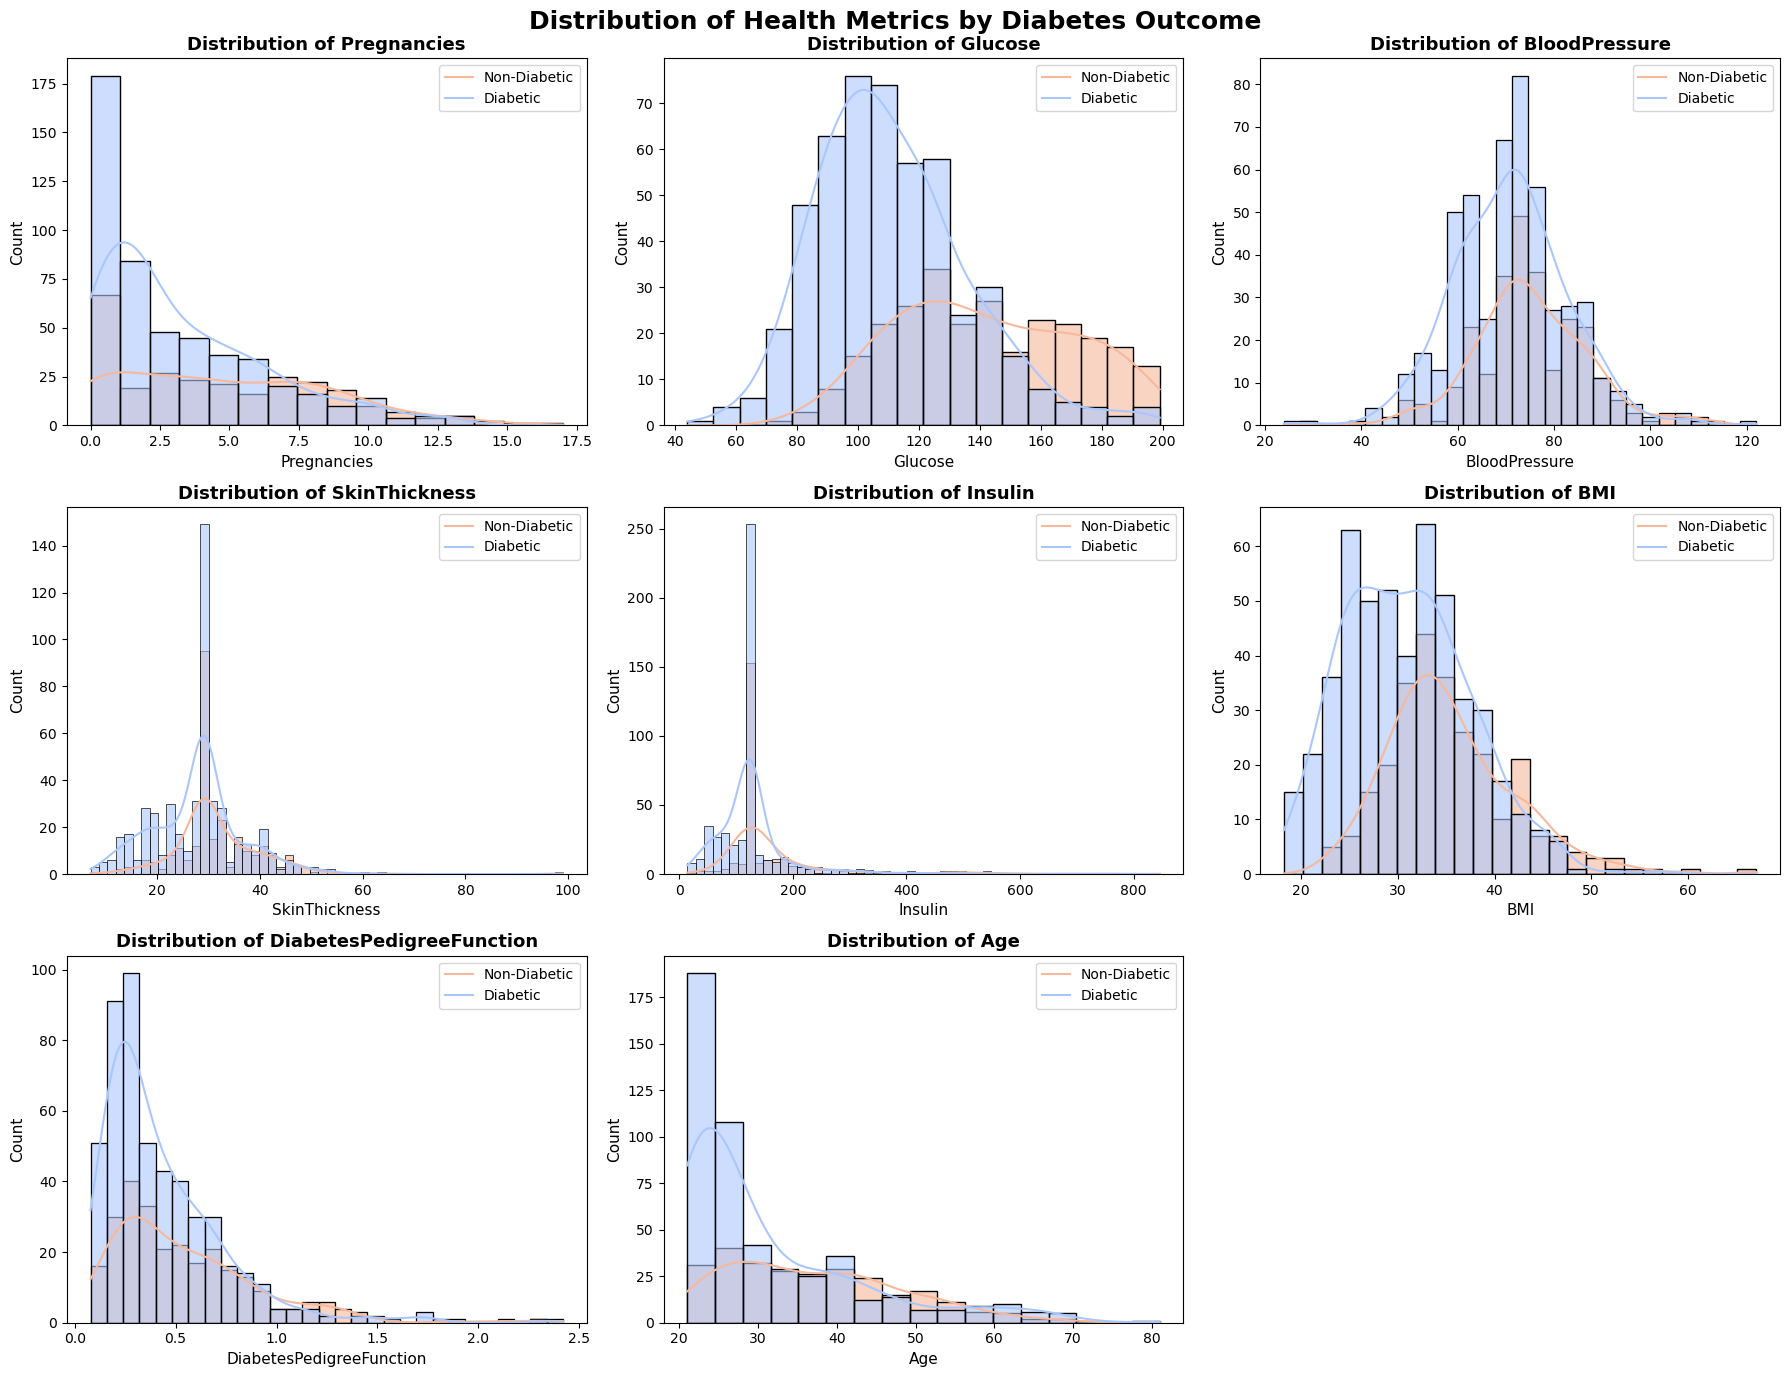

Chart 2 saved!


In [9]:
# Chart 2 - Distribution of all health metrics by Outcome
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
        'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

for i, col in enumerate(cols):
    sns.histplot(data=df, x=col, hue='Outcome', kde=True, 
                 palette='coolwarm', ax=axes[i], alpha=0.6)
    axes[i].set_title(f'Distribution of {col}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=11)
    axes[i].set_ylabel('Count', fontsize=11)
    axes[i].legend(['Non-Diabetic', 'Diabetic'], fontsize=10)

axes[8].axis('off')

plt.suptitle('Distribution of Health Metrics by Diabetes Outcome', 
             fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_folder, '2_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved!")

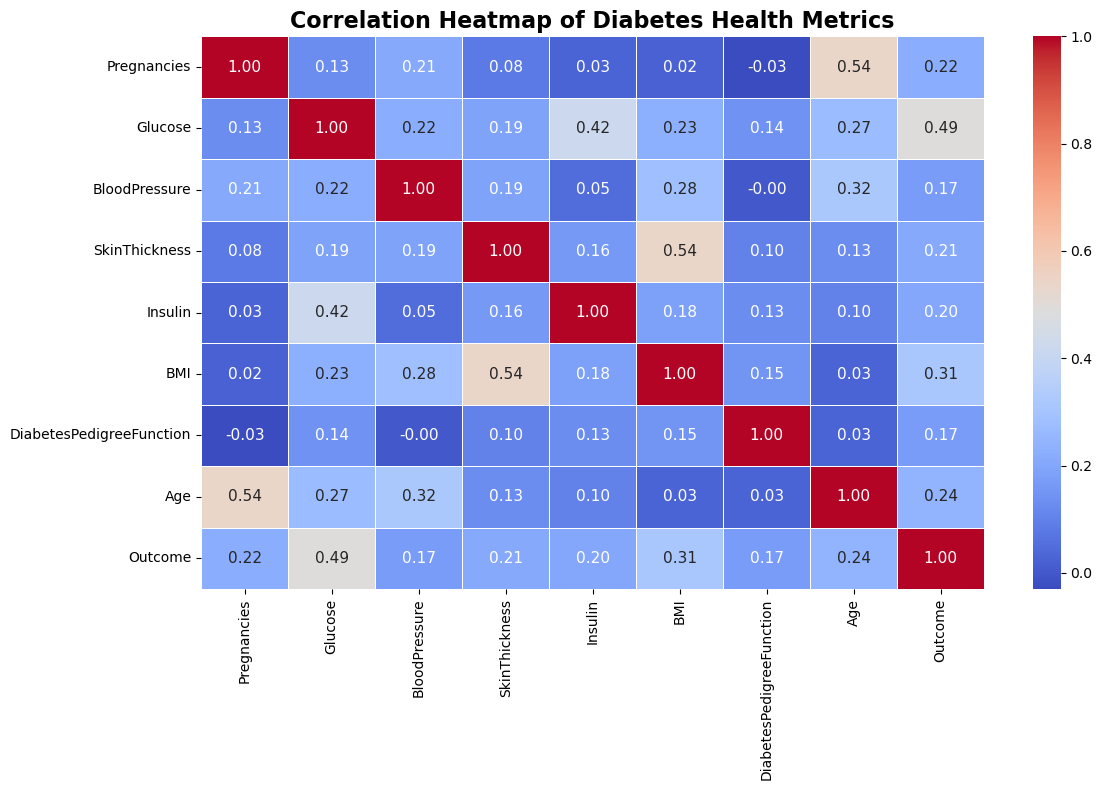

Chart 3 saved!


In [10]:
# Chart 3 - Correlation Heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr().round(2)

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    annot_kws={'size': 11}
)

plt.title('Correlation Heatmap of Diabetes Health Metrics', 
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_folder, '3_correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved!")

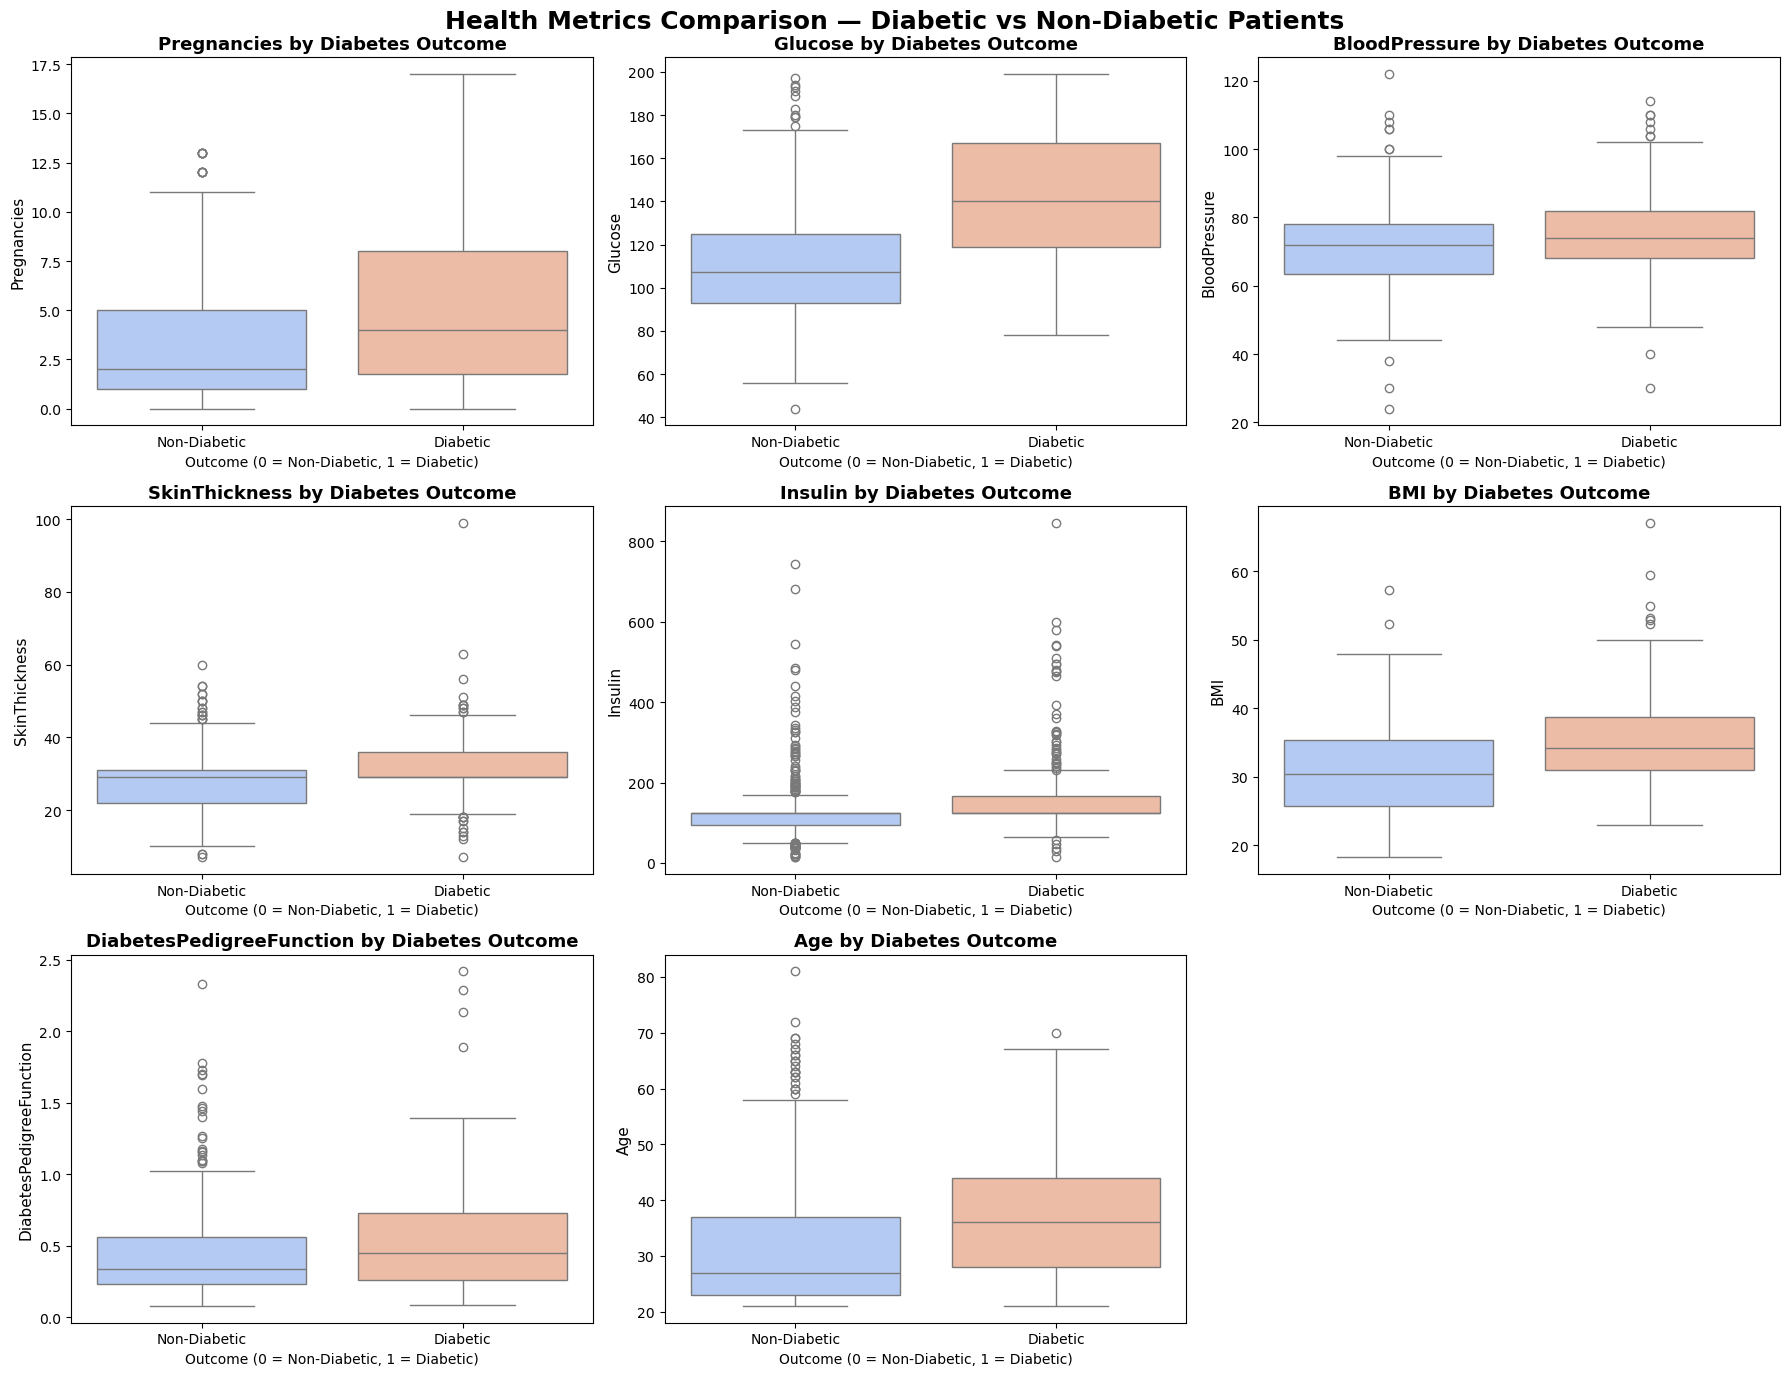

Chart 4 saved!


In [11]:
# Chart 4 - Box Plots by Outcome
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(data=df, x='Outcome', y=col, palette='coolwarm', ax=axes[i])
    axes[i].set_title(f'{col} by Diabetes Outcome', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Outcome (0 = Non-Diabetic, 1 = Diabetic)', fontsize=10)
    axes[i].set_ylabel(col, fontsize=11)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Non-Diabetic', 'Diabetic'])

axes[8].axis('off')

plt.suptitle('Health Metrics Comparison — Diabetic vs Non-Diabetic Patients',
             fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_folder, '4_boxplots.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved!")

<Figure size 640x480 with 0 Axes>

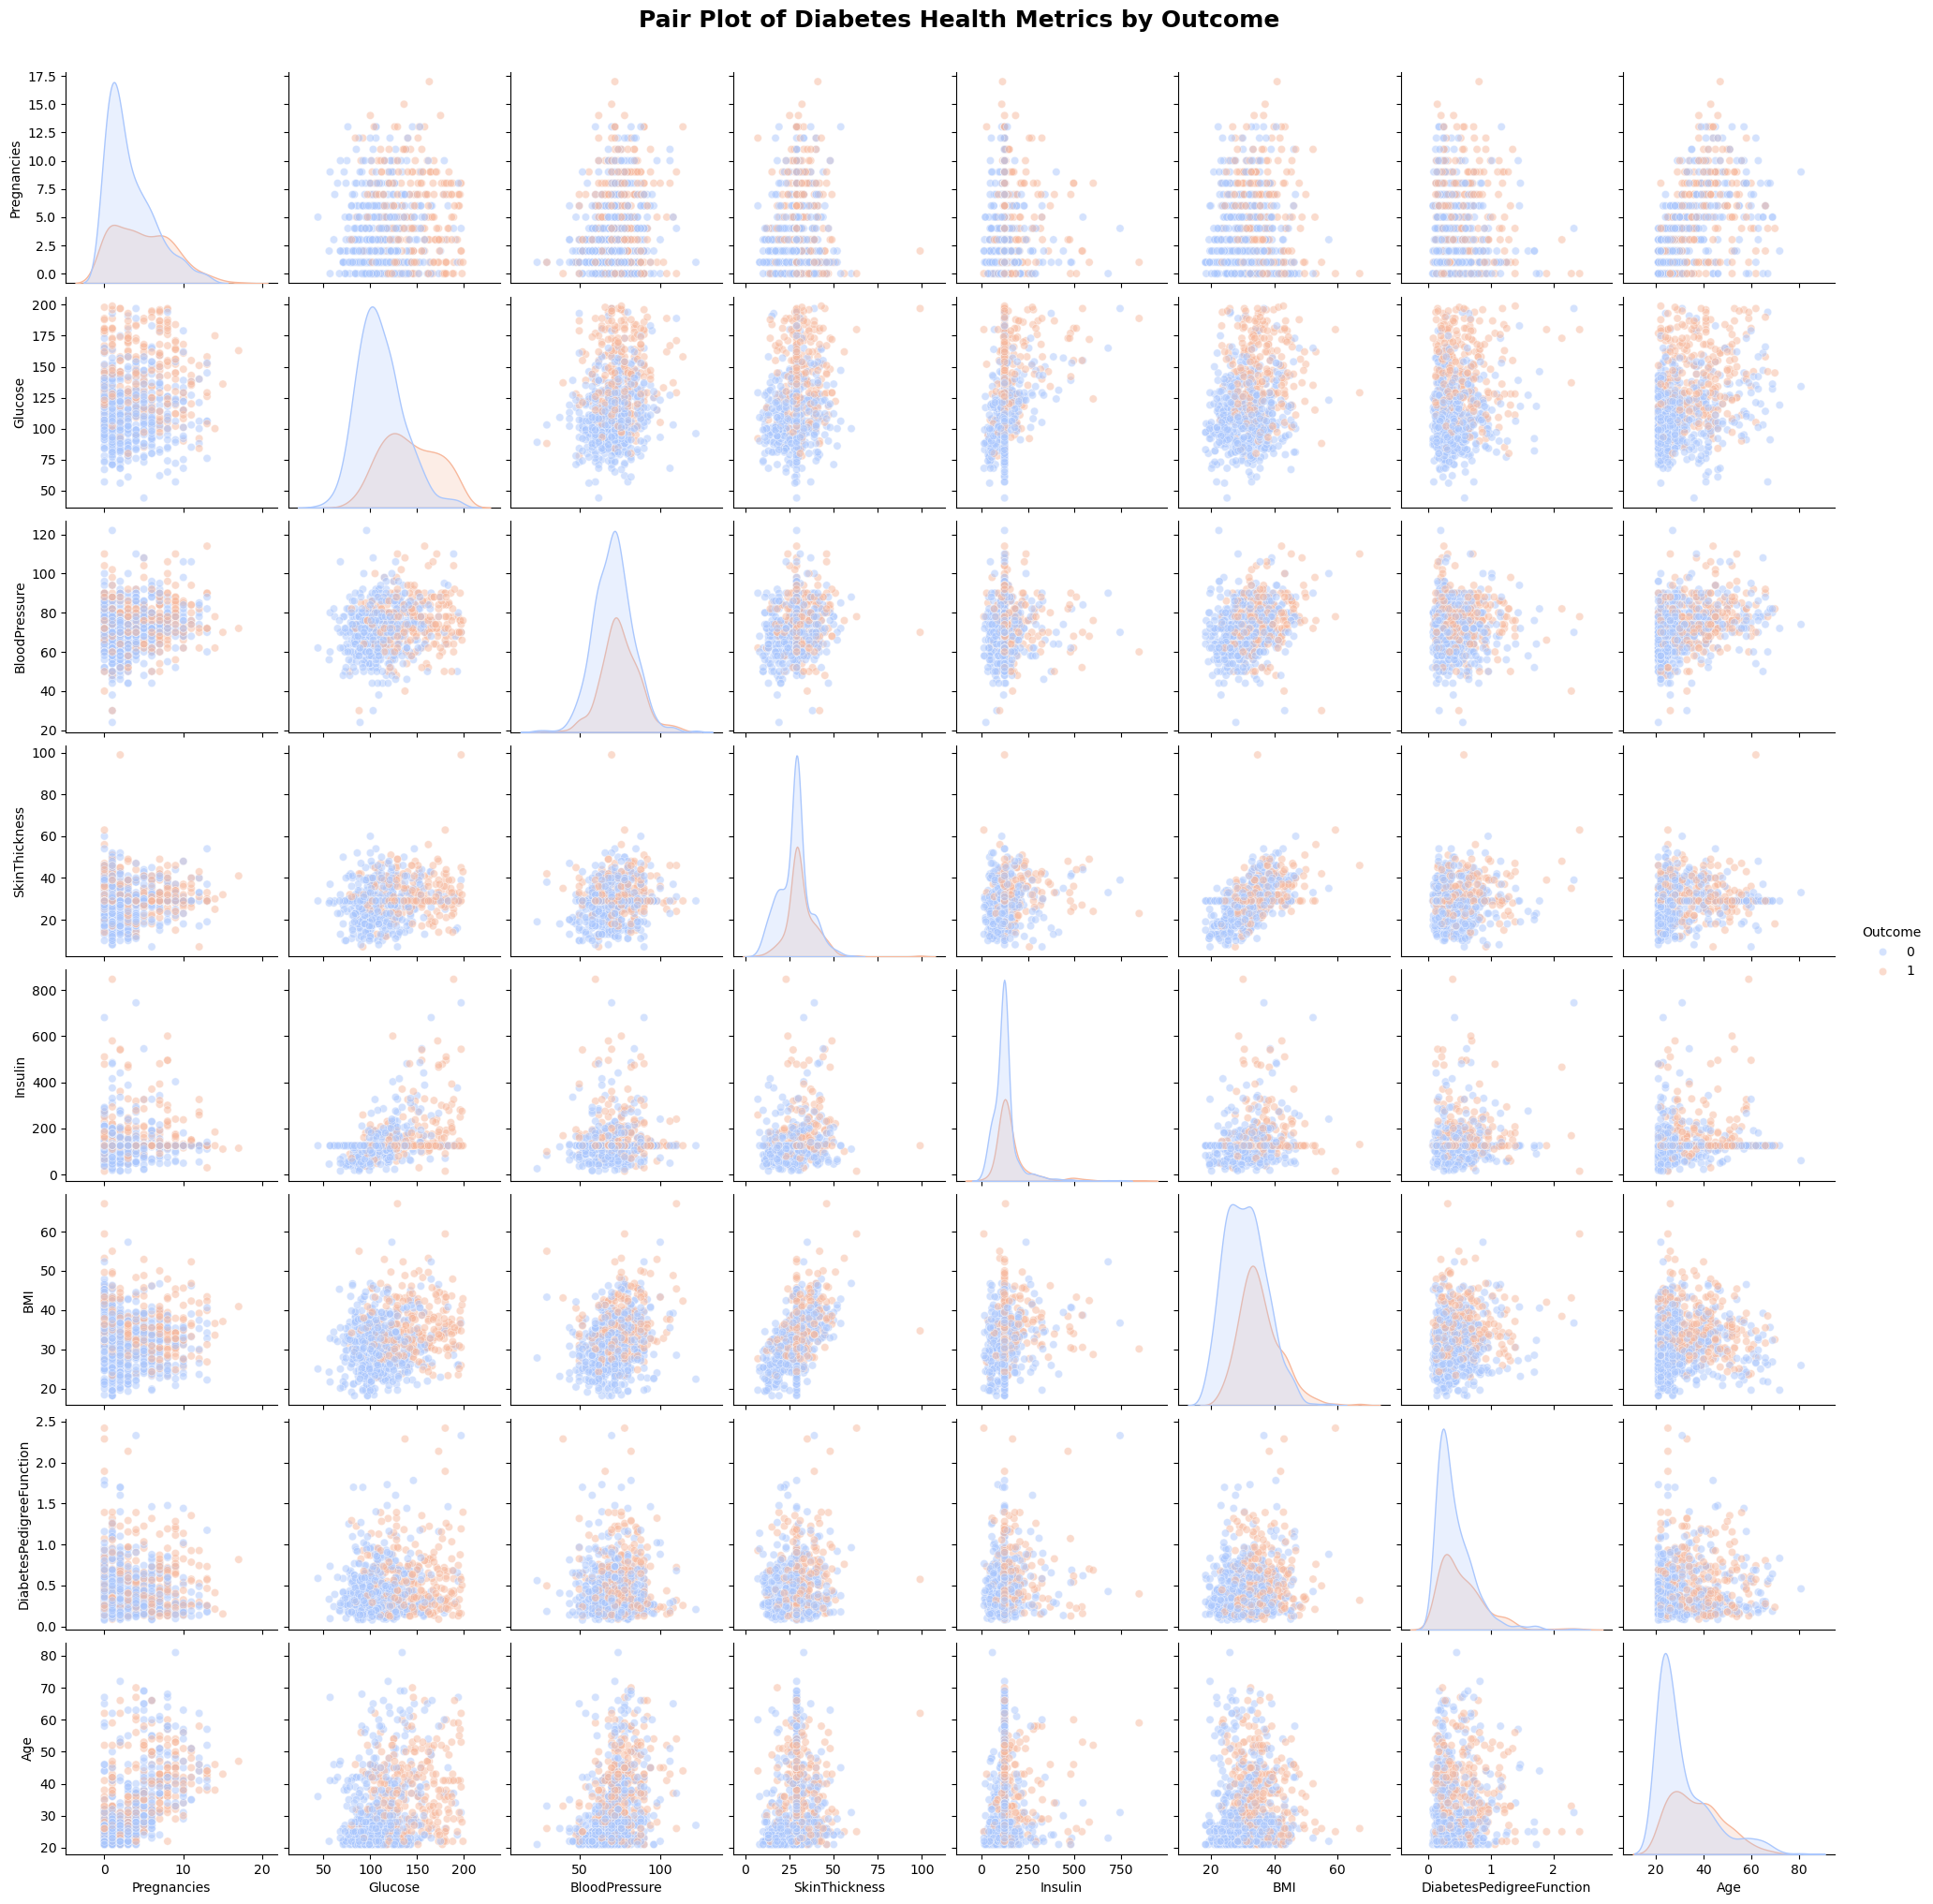

Chart 5 saved!


In [12]:
# Chart 5 - Pair Plot
plt.figure()
pair_plot = sns.pairplot(
    df,
    hue='Outcome',
    palette='coolwarm',
    diag_kind='kde',
    plot_kws={'alpha': 0.5},
    height=2.5
)

pair_plot.fig.suptitle('Pair Plot of Diabetes Health Metrics by Outcome',
                        fontsize=18, fontweight='bold', y=1.02)

pair_plot.savefig(os.path.join(output_folder, '5_pairplot.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved!")

In [13]:
# Verify all charts are saved
saved_files = os.listdir(output_folder)
print("Files saved in charts folder:")
for file in saved_files:
    print(" -", file)

Files saved in charts folder:
 - 1_outcome_distribution.png
 - 2_distributions.png
 - 3_correlation_heatmap.png
 - 4_boxplots.png
 - 5_pairplot.png


In [14]:
# EDA Summary
print("=" * 55)
print("       EDA SUMMARY — DIABETES DATASET")
print("=" * 55)

print("\nDATASET OVERVIEW:")
print(f"  Total patients: {len(df)}")
print(f"  Non-diabetic patients: {df[df['Outcome']==0].shape[0]} ({round(df[df['Outcome']==0].shape[0]/len(df)*100, 1)}%)")
print(f"  Diabetic patients: {df[df['Outcome']==1].shape[0]} ({round(df[df['Outcome']==1].shape[0]/len(df)*100, 1)}%)")

print("\nAVERAGE HEALTH METRICS — NON-DIABETIC vs DIABETIC:")
cols_to_compare = ['Glucose', 'BMI', 'Age', 'Insulin', 'BloodPressure', 'Pregnancies']
for col in cols_to_compare:
    non_diab = round(df[df['Outcome']==0][col].mean(), 1)
    diab = round(df[df['Outcome']==1][col].mean(), 1)
    print(f"  {col}: Non-Diabetic = {non_diab} | Diabetic = {diab}")

print("\nSTRONGEST DIABETES PREDICTORS (correlation with Outcome):")
correlations = df.corr()['Outcome'].drop('Outcome').sort_values(ascending=False)
for col, val in correlations.items():
    print(f"  {col}: {round(val, 3)}")

print("\n" + "=" * 55)
print("Analysis complete!")
print("=" * 55)

       EDA SUMMARY — DIABETES DATASET

DATASET OVERVIEW:
  Total patients: 768
  Non-diabetic patients: 500 (65.1%)
  Diabetic patients: 268 (34.9%)

AVERAGE HEALTH METRICS — NON-DIABETIC vs DIABETIC:
  Glucose: Non-Diabetic = 110.7 | Diabetic = 142.1
  BMI: Non-Diabetic = 30.9 | Diabetic = 35.4
  Age: Non-Diabetic = 31.2 | Diabetic = 37.1
  Insulin: Non-Diabetic = 127.8 | Diabetic = 164.7
  BloodPressure: Non-Diabetic = 70.9 | Diabetic = 75.1
  Pregnancies: Non-Diabetic = 3.3 | Diabetic = 4.9

STRONGEST DIABETES PREDICTORS (correlation with Outcome):
  Glucose: 0.493
  BMI: 0.312
  Age: 0.238
  Pregnancies: 0.222
  SkinThickness: 0.215
  Insulin: 0.204
  DiabetesPedigreeFunction: 0.174
  BloodPressure: 0.166

Analysis complete!
